/tmp/ipykernel_2668/3001042833.py:100: RuntimeWarning: invalid value encountered in subtract
  cond = (b - a) < rhs
/tmp/ipykernel_2668/3001042833.py:101: RuntimeWarning: invalid value encountered in subtract
  disc = np.maximum(2*rhs**2 - (a - b)**2, 0)
/tmp/ipykernel_2668/3001042833.py:122: RuntimeWarning: invalid value encountered in subtract
  if np.max(np.abs((p - T)[finite_new])) < eps:


[[        inf         inf         inf ...         inf         inf
          inf]
 [        inf         inf         inf ...         inf         inf
          inf]
 [        inf         inf  0.09529358 ...  9.86011368         inf
          inf]
 ...
 [        inf         inf 24.31827194 ... 28.04165935         inf
          inf]
 [        inf         inf         inf ...         inf         inf
          inf]
 [        inf         inf         inf ...         inf         inf
          inf]]


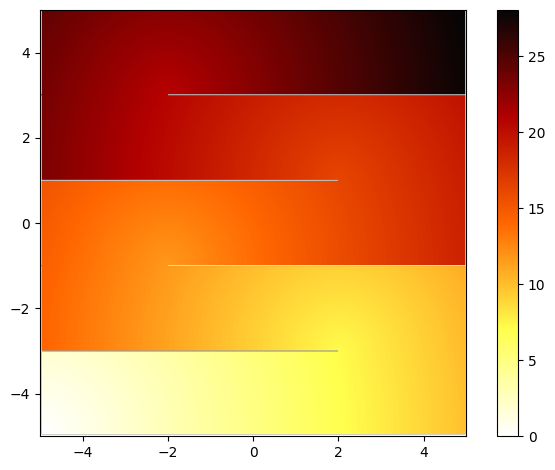

/tmp/ipykernel_2668/3001042833.py:177: RuntimeWarning: invalid value encountered in subtract
  Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
/tmp/ipykernel_2668/3001042833.py:178: RuntimeWarning: invalid value encountered in subtract
  Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
/tmp/ipykernel_2668/3001042833.py:179: RuntimeWarning: invalid value encountered in subtract
  Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
/tmp/ipykernel_2668/3001042833.py:197: RuntimeWarning: invalid value encountered in subtract
  Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
/tmp/ipykernel_2668/3001042833.py:198: RuntimeWarning: invalid value encountered in subtract
  Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
/tmp/ipykernel_2668/3001042833.py:199: RuntimeWarning: invalid value encountered in subtract
  Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy
/tmp/ipykernel_2668/3001042833.py:207: Runti

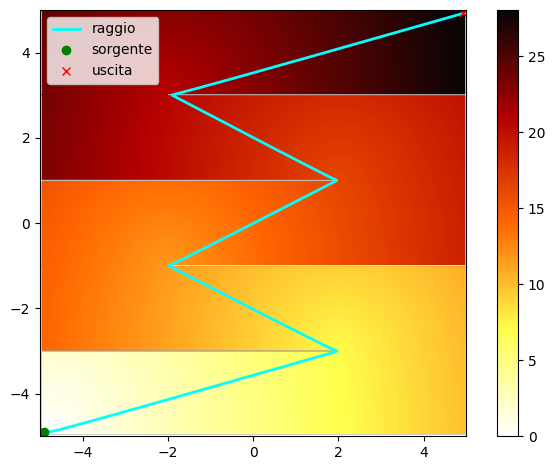

In [1]:
# ==============================================================================
#  FIM JACOBI CON GODUNOV 1 + RAGGI CON INTERP. BILINEARE SU LABIRINTO 500X500
# ==============================================================================

"""
Il seguente codice utilizza il metodo del FIM Jacobi senza lista (v3) con
l'aggiornamento di Godunov del 1° ordine per generare la soluzione T_final su cui
poi è stato integrato il raggio tramite il metodo di Rounge-Kutta del 4°ordine.
Il gradiente lo si è discretizzato con le differenze finite e interpolato
linearmente. In particolare si è usata la derivata centrata nei punti lontani
dai muri, con la backward per i punti a sx di un muro e forward per i punti alla
dx di un muro
"""

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = 1 * np.ones(X.shape)

F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1   # ← era 0.01

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1   # ← era 0.01

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1  # ← era 0.01

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1   # ← era 0.01

# ==============================================================================
# CALCOLO ICONALE
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0.0

h = dx

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

h = dx

no_wall = np.isfinite(F)

#------------------ GODUNOV 1 --------------------------------------------------

def Godunov_update_full(T, F):
    # maschera nodi percorribili
    passable = np.isfinite(F)
    T_pass = np.where(passable, T, np.inf)  # i muri appaiono come inf ai vicini

    left  = np.full_like(T, np.inf);  left[:,  1:]  = T_pass[:, :-1]
    right = np.full_like(T, np.inf);  right[:, :-1] = T_pass[:,  1:]
    down  = np.full_like(T, np.inf);  down[1:,  :]  = T_pass[:-1, :]
    up    = np.full_like(T, np.inf);  up[:-1,   :]  = T_pass[1:,  :]

    Txmin = np.minimum(left, right)
    Tymin = np.minimum(down, up)

    a = np.minimum(Txmin, Tymin)
    b = np.maximum(Txmin, Tymin)

    rhs  = h / F
    cond = (b - a) < rhs
    disc = np.maximum(2*rhs**2 - (a - b)**2, 0)

    u_quad = (a + b + np.sqrt(disc)) / 2
    u_lin  = a + rhs

    u = np.where(cond, u_quad, u_lin)
    u[~passable] = np.inf

    return u

#------------------  AGGIORNAMENTO FIM-JACOBI ----------------------------------

def FIM_senzaLista(T, F):

    while True:
        p = T.copy()
        q = Godunov_update_full(T, F)
        T = np.minimum(p, q)

        finite_new = np.isfinite(T)
        if not np.any(finite_new):
            break
        if np.max(np.abs((p - T)[finite_new])) < eps:
            break

    return T

T_final = FIM_senzaLista(T, F)

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI (INTERP.BILINEARE + RK4)
# ==============================================================================

#------------------ DISCRETIZZAZIONE DEL GRADIENTE -----------------------------

def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)

#------------------  ADATTAMENTO DEI MURI --------------------------------------

def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]

#------------------  INTERPOLAZIONE BILINEARE ----------------------------------

wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)



def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])

#------------------  INTEGRAZIONE RK4 ------------------------------------------

def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CALCOLO DEL RAGGIO ALL'INDIETRO ---------------------------

# coordinate cartesiane del punto sorgente (coerenti con ix0, iy0)
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio (esempio: vicino all'angolo)
exit_pt = (x[495], y[495])   # scegli tu la cella esatta, deve essere F finito lì

ds = dx  # passo di integrazione, puoi anche provare dx/2 per più precisione
max_steps = 5000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2668/1054228573.py:118: RuntimeWarning: invalid value encountered in subtract
  cond = (b - a) < rhs
/tmp/ipykernel_2668/1054228573.py:119: RuntimeWarning: invalid value encountered in subtract
  disc = np.maximum(2*rhs**2 - (a - b)**2, 0)
/tmp/ipykernel_2668/1054228573.py:140: RuntimeWarning: invalid value encountered in subtract
  if np.max(np.abs((p - T)[finite_new])) < eps:


[[        inf         inf         inf ...         inf         inf
          inf]
 [        inf         inf         inf ...         inf         inf
          inf]
 [        inf         inf  0.31764528 ... 10.11464446         inf
          inf]
 ...
 [        inf         inf 24.98885386 ... 28.86124107         inf
          inf]
 [        inf         inf         inf ...         inf         inf
          inf]
 [        inf         inf         inf ...         inf         inf
          inf]]


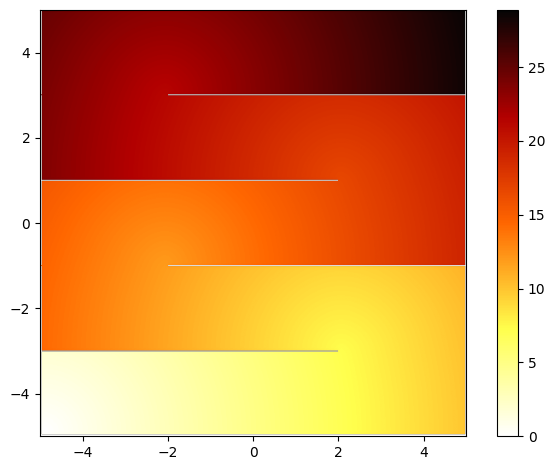

/tmp/ipykernel_2668/1054228573.py:195: RuntimeWarning: invalid value encountered in subtract
  Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
/tmp/ipykernel_2668/1054228573.py:196: RuntimeWarning: invalid value encountered in subtract
  Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
/tmp/ipykernel_2668/1054228573.py:197: RuntimeWarning: invalid value encountered in subtract
  Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
/tmp/ipykernel_2668/1054228573.py:215: RuntimeWarning: invalid value encountered in subtract
  Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
/tmp/ipykernel_2668/1054228573.py:216: RuntimeWarning: invalid value encountered in subtract
  Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
/tmp/ipykernel_2668/1054228573.py:217: RuntimeWarning: invalid value encountered in subtract
  Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy
/tmp/ipykernel_2668/1054228573.py:225: Runti

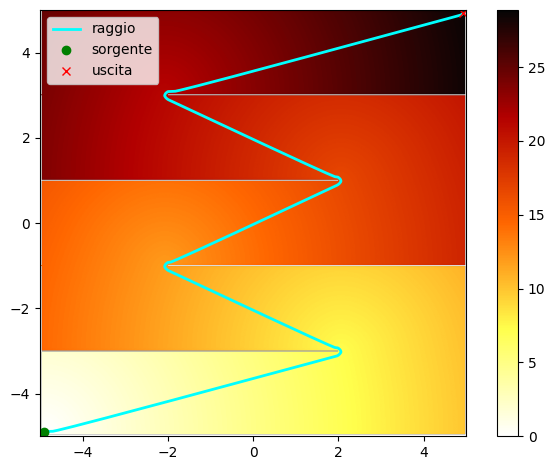

In [2]:
# ======================================================================================
# FIM JACOBI CON GODUNOV 1 + RAGGI CON INTERP. BILINEARE SU LABIRINTO 500X500 CON F_SAFE
# ======================================================================================

"""
in questo codice è stato implementato lo stesso algoritmo di prima ma su di una
F = F_safe che definisce una fascia morbida intorno ai muri in modo da
scoraggiare il robottino a rasentare i muri ed evitare quindi collisioni.
"""

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import binary_dilation

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

#ix0 = x.tolist().index(min(abs(x - 0)))
#iy0 = y.tolist().index(min(abs(y - 0)))

ix0 = 5
iy0 = 5

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = 1 * np.ones(X.shape)

F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1   # ← era 0.01

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1   # ← era 0.01

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1  # ← era 0.01

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1   # ← era 0.01


wall_mask = np.isinf(F)

#------------------  FASCIA DI SICUREZZA AI MURI -------------------------------

def inflate_walls(F, wall_mask, margin_cells=3, penalty_factor=0.3):
    """
    Riduce F (velocità) nelle celle vicine ai muri, creando una zona
    di 'costo maggiorato' che spinge i percorsi lontano dagli spigoli.
    """
    F_inflated = F.copy()
    dilated = binary_dilation(wall_mask, iterations=margin_cells)
    near_wall = dilated & ~wall_mask   # celle libere vicine al muro, ma non muro

    F_inflated[near_wall] = penalty_factor   # più basso = più "costoso" passarci

    return F_inflated

F_safe = inflate_walls(F, wall_mask, margin_cells=3, penalty_factor=0.3)

# ==============================================================================
# CALCOLO ICONALE
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0.0


h = dx

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

h = dx

no_wall = np.isfinite(F)

#------------------ GODUNOV 1 --------------------------------------------------

def Godunov_update_full(T, F_safe):
    # maschera nodi percorribili
    passable = np.isfinite(F)
    T_pass = np.where(passable, T, np.inf)  # i muri appaiono come inf ai vicini

    left  = np.full_like(T, np.inf);  left[:,  1:]  = T_pass[:, :-1]
    right = np.full_like(T, np.inf);  right[:, :-1] = T_pass[:,  1:]
    down  = np.full_like(T, np.inf);  down[1:,  :]  = T_pass[:-1, :]
    up    = np.full_like(T, np.inf);  up[:-1,   :]  = T_pass[1:,  :]

    Txmin = np.minimum(left, right)
    Tymin = np.minimum(down, up)

    a = np.minimum(Txmin, Tymin)
    b = np.maximum(Txmin, Tymin)

    rhs  = h / F_safe
    cond = (b - a) < rhs
    disc = np.maximum(2*rhs**2 - (a - b)**2, 0)

    u_quad = (a + b + np.sqrt(disc)) / 2
    u_lin  = a + rhs

    u = np.where(cond, u_quad, u_lin)
    u[~passable] = np.inf

    return u

#------------------  AGGIORNAMENTO FIM-JACOBI ----------------------------------

def FIM_senzaLista(T, F_safe):

    while True:
        p = T.copy()
        q = Godunov_update_full(T, F_safe)
        T = np.minimum(p, q)

        finite_new = np.isfinite(T)
        if not np.any(finite_new):
            break
        if np.max(np.abs((p - T)[finite_new])) < eps:
            break

    return T

T_final = FIM_senzaLista(T, F_safe)
print(T_final)

#------------------ STAMPA DEI RISULTATI ---------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI
# ==============================================================================

#------------------ DISCRETIZZAZIONE DEL GRADIENTE -----------------------------

def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)

#------------------  ADATTAMENTO DEI MURI --------------------------------------

def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]

#------------------  INTERPOLAZIONE BILINEARE ----------------------------------

wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)


def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])

#------------------  INTEGRAZIONE RK4 ------------------------------------------

def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CALCOLO DEL RAGGIO ALL'INDIETRO ---------------------------

# coordinate cartesiane del punto sorgente (coerenti con ix0, iy0)
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio (esempio: vicino all'angolo)
exit_pt = (x[495], y[495])   # scegli tu la cella esatta, deve essere F finito lì

ds = dx  # passo di integrazione, puoi anche provare dx/2 per più precisione
max_steps = 5000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()